In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# import the dataset
data = pd.read_csv('engine_lab_output.csv')

data.head()

,Source File,Industry,Date,Project ID,Umbrella Project ID,Project Name,Owner Name,Plant Name,Umbrella Project Name,TIV (USD),...,New Building Size (Sq. Ft.),AFE date,Sub Bid Doc,Completion,Equip RFQ,Kick-Off,Kickoff Slippage,Duration,Project Probability,PEC Activity
0,Engine Lab 6.pdf,Industrial Manufacturing,18-Dec-2025,300426376,79513.0,REMINGTON (FAUQUIER) HYPERSCALE DATA CENTER EX...,PointOne,Remington (Fauquier) Data Center Campus,POINTONE DATA CENTER CAMPUS REMINGTON,460000000,...,"235,450",2028-12,2029-02,31-Jul-2030,2029-02,2029-03,NaN,17 Months,Medium (70-80%),Project Scope
1,Engine Lab 6.pdf,Industrial Manufacturing,18-Dec-2025,300426378,79513.0,REMINGTON (FAUQUIER) HYPERSCALE DATA CENTER EX...,PointOne,Remington (Fauquier) Data Center Campus,POINTONE DATA CENTER CAMPUS REMINGTON,460000000,...,"173,000",2029-12,2030-02,31-Jul-2031,2030-02,2030-03,NaN,17 Months,Medium (70-80%),Project Scope
2,Engine Lab 8.pdf,Industrial Manufacturing,02-Oct-2025,300578459,74821.0,SACRAMENTO DATA CENTER CAMPUS 40 MW PHASE 3 EX...,Prime Data Centers,Sacramento Data Center Campus (SMF01-01),PRIME DATA CENTERS SMF01-02 SACRAMENTO DATA CE...,400000000,...,NaN,2029-01,2029-03,30-Jun-2030,2029-03,2029-04,73 Months,NaN,Medium (70-80%),Market Analysis
3,Engine Lab 3.pdf,Industrial Manufacturing,06-Feb-2026,300782061,81461.0,WAUKEE DATA CENTER EXPANSION (PROJECT MORGAN) ...,Apple Incorporated,Waukee Data Center (Project Morgan),APPLE PROJECT MORGAN WKE SITE EXPANSION,1380000000,...,"315,800",2029-04,2029-05,29-Jun-2030,2029-05,2029-06,24 Months,NaN,Medium (70-80%),Market Analysis
4,Engine Lab 8.pdf,Industrial Manufacturing,02-Oct-2025,300808411,74841.0,UNION 50MW DATA CENTER EXPANSION BUILDING 5,Google Incorporated,Omaha UNO1A Data Center (Project Sarpy),OMAHA GRASSROOT 50MW UNO1A DATA CENTER CAMPUS ...,500000000,...,"286,000",2029-03,2029-04,31-Dec-2030,2029-04,2029-05,36 Months,20 Months,Medium (70-80%),Market Analysis


## EDA


### missing values overview

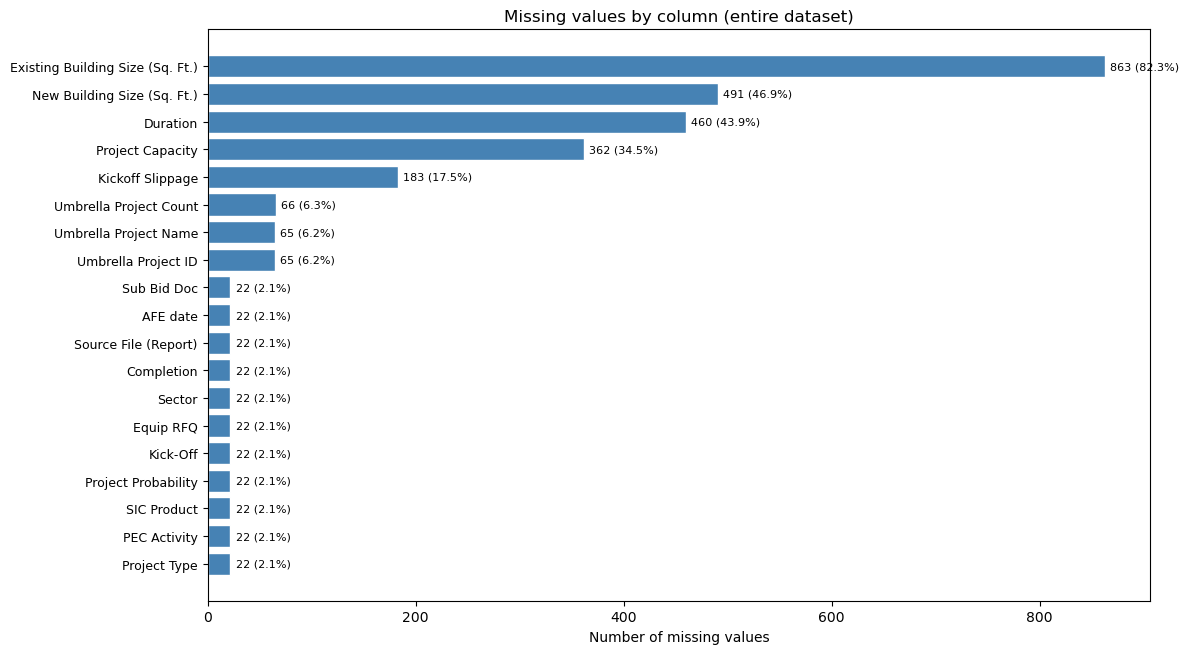

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data (or use your existing `data`)
data = pd.read_csv('engine_lab_output.csv')

# Missing count and share per column
missing_count = data.isna().sum()
missing_pct = (data.isna().sum() / len(data)) * 100
missing = pd.DataFrame({
    'count': missing_count,
    'pct': missing_pct
}).sort_values('count', ascending=False)

# Keep only columns with at least one missing value
missing = missing[missing['count'] > 0]

if len(missing) == 0:
    print("No missing values in the dataset.")
else:
    fig, ax = plt.subplots(figsize=(12, max(6, len(missing) * 0.35)))
    y_pos = np.arange(len(missing))
    bars = ax.barh(y_pos, missing['count'], color='steelblue', edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(missing.index, fontsize=9)
    ax.set_xlabel('Number of missing values')
    ax.set_title('Missing values by column (entire dataset)')
    ax.invert_yaxis()  # highest count at top
    for i, (cnt, pct) in enumerate(zip(missing['count'], missing['pct'])):
        ax.text(cnt + 5, i, f'{int(cnt)} ({pct:.1f}%)', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

Three of the most important variables: Project Capacity, Existing Building Size, New Building Size, have a good amount of missing values. We will perform some EDA to do some initial filtering and conclude the best imputation method.

### distribution of project type

Project Type
Plant Expansion    1023
Unit Addition         2
Grassroot             1
Name: count, dtype: int64


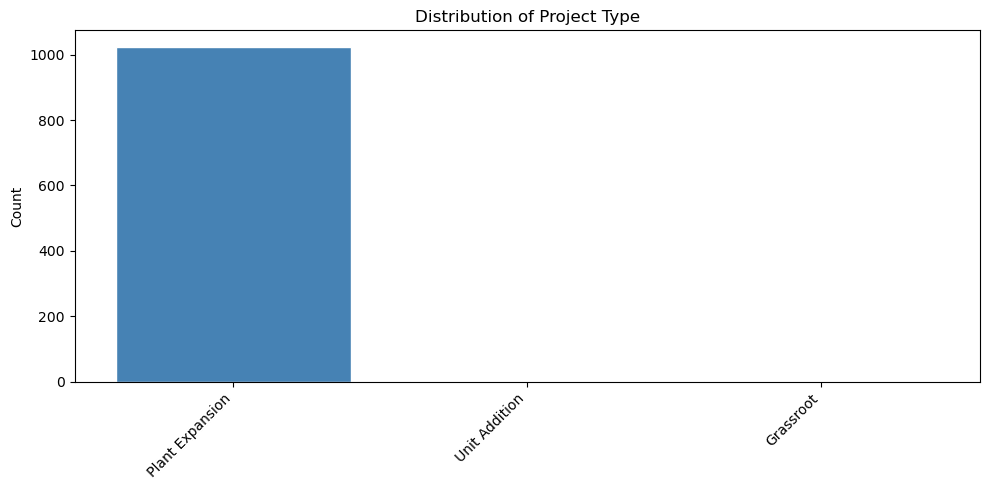

In [4]:
counts = data['Project Type'].value_counts()
print(counts)

plt.figure(figsize=(10, 5))
plt.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
plt.xticks(range(len(counts)), counts.index, rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Distribution of Project Type')
plt.tight_layout()
plt.show()

we can see most projects are expansino of some existing plant, which will be the main focus of out beach head

### distribution of kickoff slippage

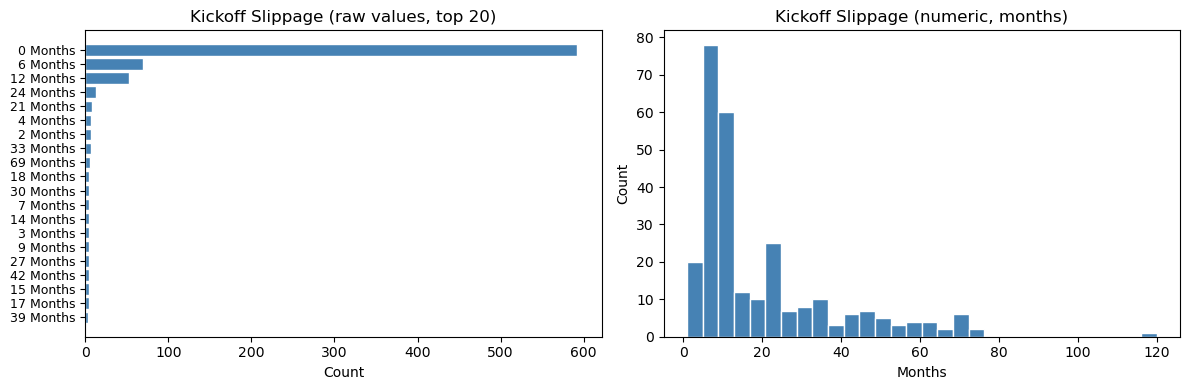

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

col = 'Kickoff Slippage'

# Missing
n_missing = data[col].isna().sum()
#print(f"Missing: {n_missing} ({100 * n_missing / len(data):.1f}%)")

# Value counts (raw strings)
#print("\nValue counts (raw):")
#print(data[col].value_counts(dropna=False).head(30))

# Extract number from "N Months"
slippage_str = data[col].astype(str)
slippage_num = slippage_str.str.extract(r'(\d+)', expand=False).astype(float)
slippage_num = slippage_num.replace(0, np.nan)  # optional: treat 0 as missing

valid = slippage_num.dropna()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar chart of raw categories (top 20)
counts = data[col].value_counts()
axes[0].barh(range(min(20, len(counts))), counts.values[:20], color='steelblue', edgecolor='white')
axes[0].set_yticks(range(min(20, len(counts))))
axes[0].set_yticklabels(counts.index[:20], fontsize=9)
axes[0].set_xlabel('Count')
axes[0].set_title('Kickoff Slippage (raw values, top 20)')
axes[0].invert_yaxis()

# Right: histogram of numeric values (months)
axes[1].hist(valid, bins=min(30, int(valid.max() - valid.min() + 1)), color='steelblue', edgecolor='white')
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Count')
axes[1].set_title('Kickoff Slippage (numeric, months)')

plt.tight_layout()
plt.show()

from the distribution, we can see that a project with over 60 months of slippage is considered out of the norm, and tend to have higher chances to slip again. To minimize the risk of rescheduling and hurting the timeline. we are going to remove the projects with historical slippage of over 60 months.

In [6]:
data['Kickoff Slippage Months'] = (
    data['Kickoff Slippage']
    .str.extract(r'(\d+)')
    .astype(float)
)

# Keep rows where slippage is <= 40 months OR slippage is missing
data_1 = data[(data['Kickoff Slippage Months'] <= 60) | (data['Kickoff Slippage Months'].isna())]

print(f'Rows kept: {len(data_1)} / {len(data)}')
print(f'Missing slippage preserved: {data_1["Kickoff Slippage Months"].isna().sum()}')


Rows kept: 1033 / 1048
Missing slippage preserved: 183


### distribution of kickoff date

Kick-Off missing: 22 / 1033 (2.1%)


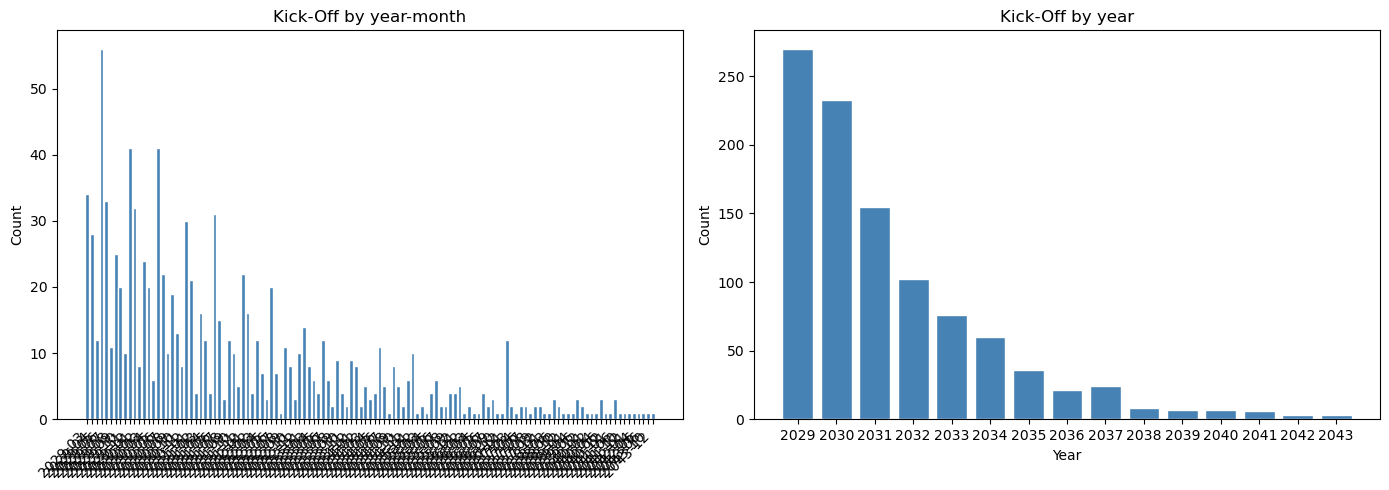

In [7]:
n_missing = data_1['Kick-Off'].isna().sum()
n_total = len(data_1)
print(f"Kick-Off missing: {n_missing} / {n_total} ({100 * n_missing / n_total:.1f}%)")


kickoff = pd.to_datetime(data_1['Kick-Off'], format='%Y-%m', errors='coerce').dropna()
# Left: by year-month (existing)
counts_month = kickoff.value_counts().sort_index()
# Right: by year
counts_year = kickoff.dt.year.value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1 — by year-month
axes[0].bar(range(len(counts_month)), counts_month.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(counts_month)))
axes[0].set_xticklabels([d.strftime('%Y-%m') for d in counts_month.index], rotation=45, ha='right')
axes[0].set_ylabel('Count')
axes[0].set_title('Kick-Off by year-month')
# Plot 2 — by year
axes[1].bar(counts_year.index.astype(str), counts_year.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].set_title('Kick-Off by year')
plt.tight_layout()
plt.show()

we can see a very long tail int erms of kickoff time, and sine ivnesting in a project that plans to build too far in the future is bad for realizing value in time, we want to filter out projects that has kickoff-time further than 2036 (include 2036), also getting rid of projects missing kickoff time.

In [8]:
kickoff = pd.to_datetime(data_1['Kick-Off'], format='%Y-%m', errors='coerce')
data_2 = data_1[kickoff.notna() & (kickoff.dt.year <= 2036)].copy()

print(f"data_1: {len(data_1)} rows  →  data_2: {len(data_2)} rows")

data_1: 1033 rows  →  data_2: 953 rows


### distribution of capacity and building size

In [9]:
# 'New Building Size (Sq. Ft.)' contains commas (e.g. '180,000') — strip them before converting
# Zero values (raw '0') are excluded as they are data entry errors
building_size = (
    data_2['New Building Size (Sq. Ft.)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
    .dropna()
)
building_size = building_size[building_size > 0]

# 'Project Capacity' contains text like '113 MW of Data Center Load' — extract the leading number
project_capacity = (
    data_2['Project Capacity']
    .astype(str)
    .str.extract(r'([\d.]+)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
    .dropna()
)

print(f"New Building Size  — non-null count: {len(building_size)}")
print(building_size.describe())
print()
print(f"Project Capacity   — non-null count: {len(project_capacity)}")
print(project_capacity.describe())

New Building Size  — non-null count: 530
count    5.300000e+02
mean     3.293692e+05
std      1.801329e+05
min      1.250000e+04
25%      2.290660e+05
50%      2.850000e+05
75%      3.794000e+05
max      1.361182e+06
Name: New Building Size (Sq. Ft.), dtype: float64

Project Capacity   — non-null count: 632
count    632.000000
mean      71.656329
std       53.673332
min        0.000000
25%       45.000000
50%       60.000000
75%       85.000000
max      320.000000
Name: Project Capacity, dtype: float64


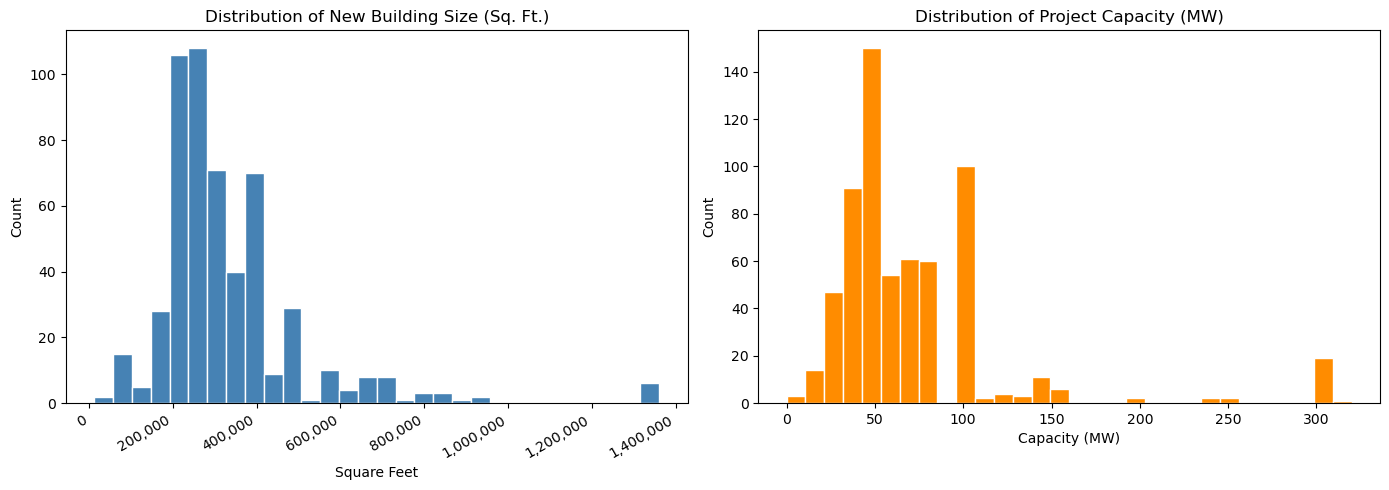

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- New Building Size ---
axes[0].hist(building_size, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of New Building Size (Sq. Ft.)')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# --- Project Capacity ---
axes[1].hist(project_capacity, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Project Capacity (MW)')
axes[1].set_xlabel('Capacity (MW)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### capacity vs new building size

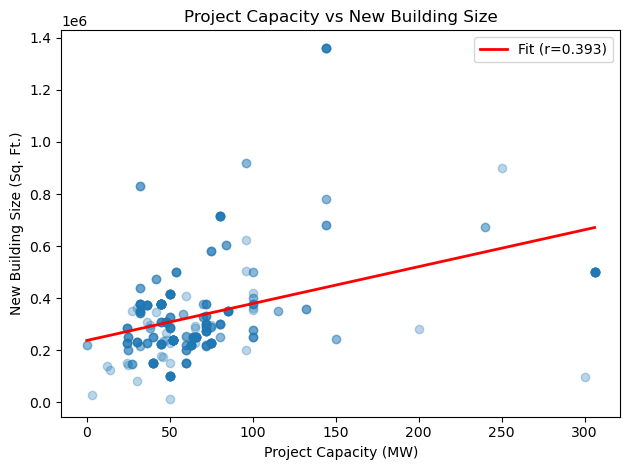

In [11]:
# plot the scatter plot of capacity vs new building size
from scipy import stats

mask = building_size.notna() & project_capacity.notna()
x = project_capacity[mask]
y = building_size[mask]

plt.scatter(x, y, alpha=0.3)
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'Fit (r={r:.3f})')
plt.xlabel('Project Capacity (MW)')
plt.ylabel('New Building Size (Sq. Ft.)')
plt.title('Project Capacity vs New Building Size')
plt.legend()
plt.tight_layout()
plt.show()

#### by state

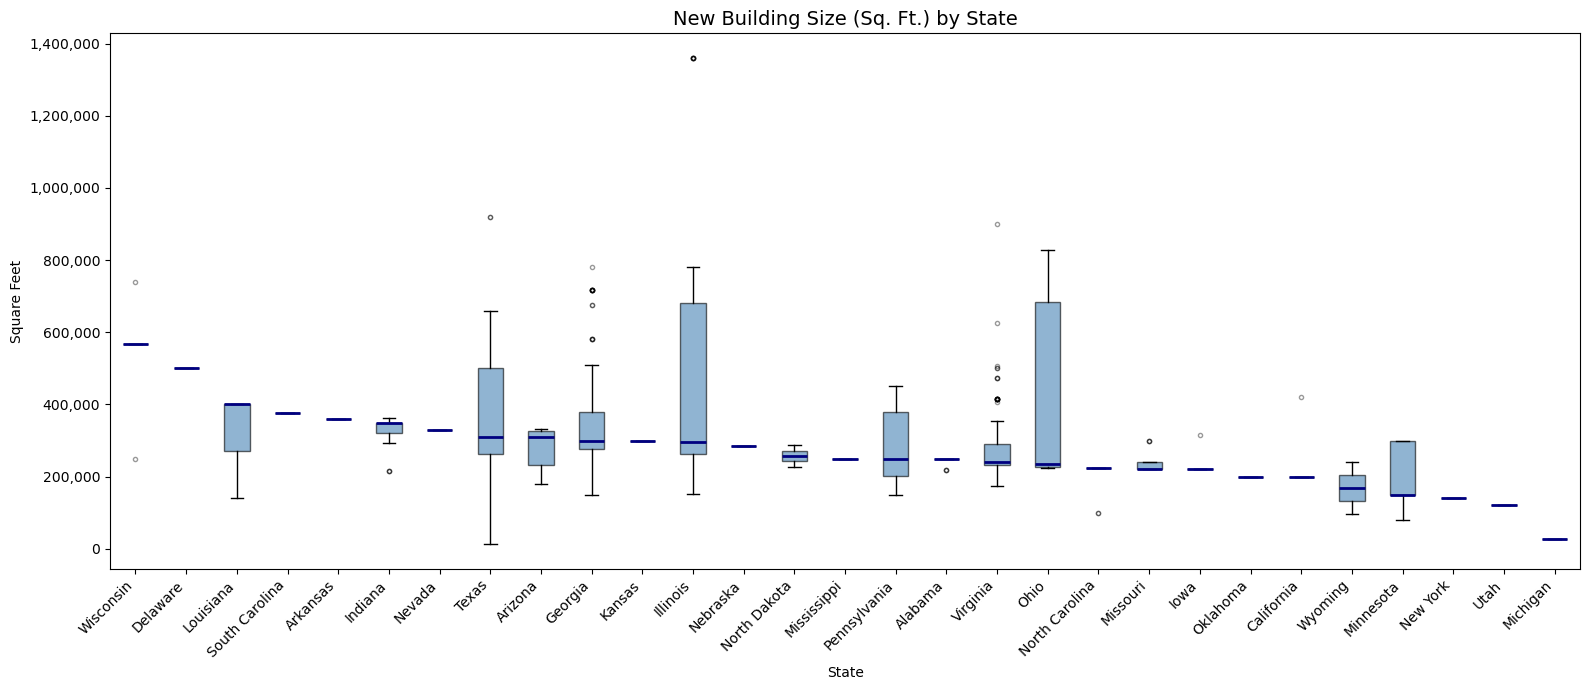

In [12]:
# --- New Building Size by State ---
bs_state = data_2[['State', 'New Building Size (Sq. Ft.)']].copy()
bs_state['New Building Size (Sq. Ft.)'] = (
    bs_state['New Building Size (Sq. Ft.)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
bs_state = bs_state[bs_state['New Building Size (Sq. Ft.)'] > 0].dropna()

# Order states by median building size
state_order_bs = (
    bs_state.groupby('State')['New Building Size (Sq. Ft.)']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 7))
groups_bs = [bs_state.loc[bs_state['State'] == s, 'New Building Size (Sq. Ft.)'].values for s in state_order_bs]
ax.boxplot(groups_bs, labels=state_order_bs, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='navy', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('New Building Size (Sq. Ft.) by State', fontsize=14)
ax.set_xlabel('State')
ax.set_ylabel('Square Feet')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

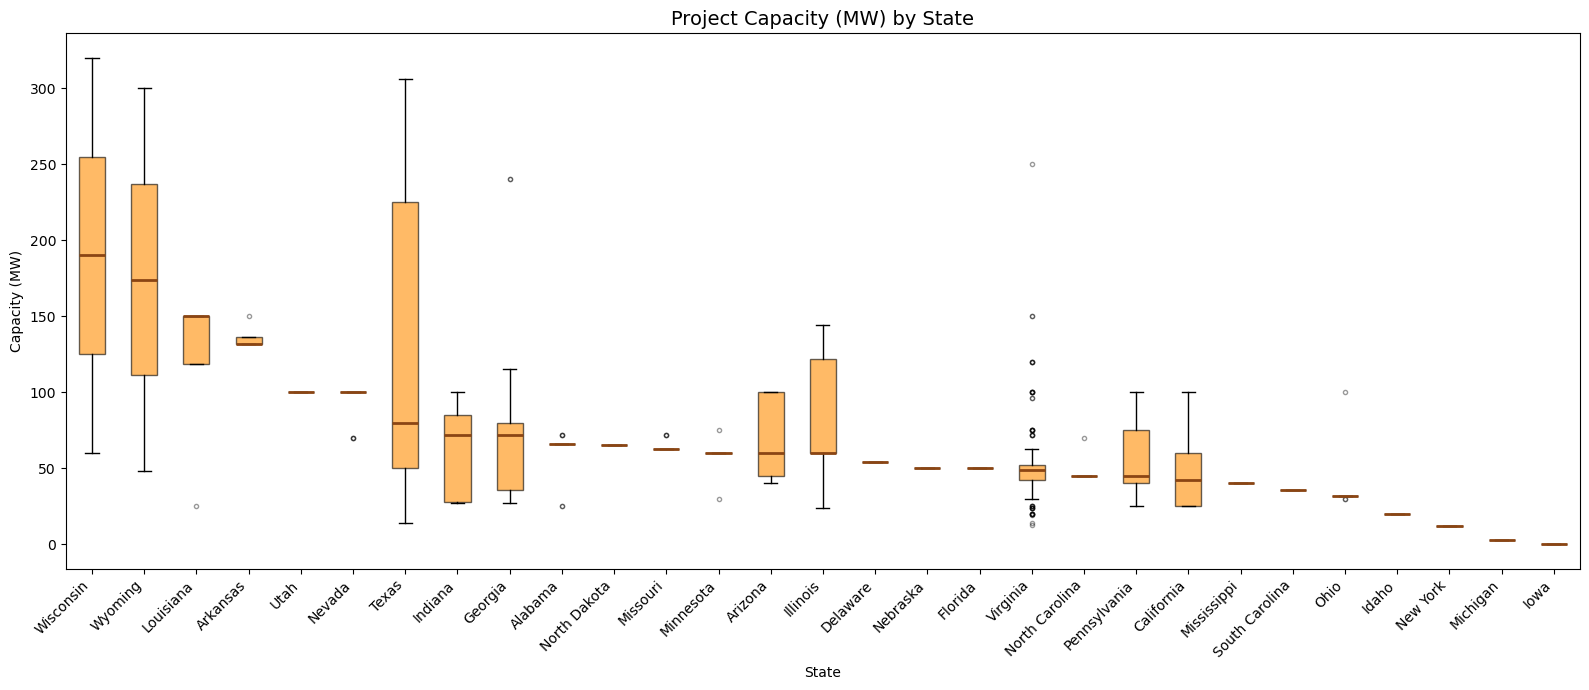

In [13]:
# --- Project Capacity by State ---
pc_state = data_2[['State', 'Project Capacity']].copy()
pc_state['Project Capacity'] = (
    pc_state['Project Capacity']
    .astype(str)
    .str.extract(r'([\d.]+)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
)
pc_state = pc_state.dropna()

# Order states by median capacity
state_order_pc = (
    pc_state.groupby('State')['Project Capacity']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 7))
groups_pc = [pc_state.loc[pc_state['State'] == s, 'Project Capacity'].values for s in state_order_pc]
ax.boxplot(groups_pc, labels=state_order_pc, patch_artist=True,
           boxprops=dict(facecolor='darkorange', alpha=0.6),
           medianprops=dict(color='saddlebrown', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('Project Capacity (MW) by State', fontsize=14)
ax.set_xlabel('State')
ax.set_ylabel('Capacity (MW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### missing value by state

C:\Users\brian\AppData\Local\Temp\ipykernel_15000\1354171433.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ((g['bs'].isna()) & (g['pc'].isna())).sum())


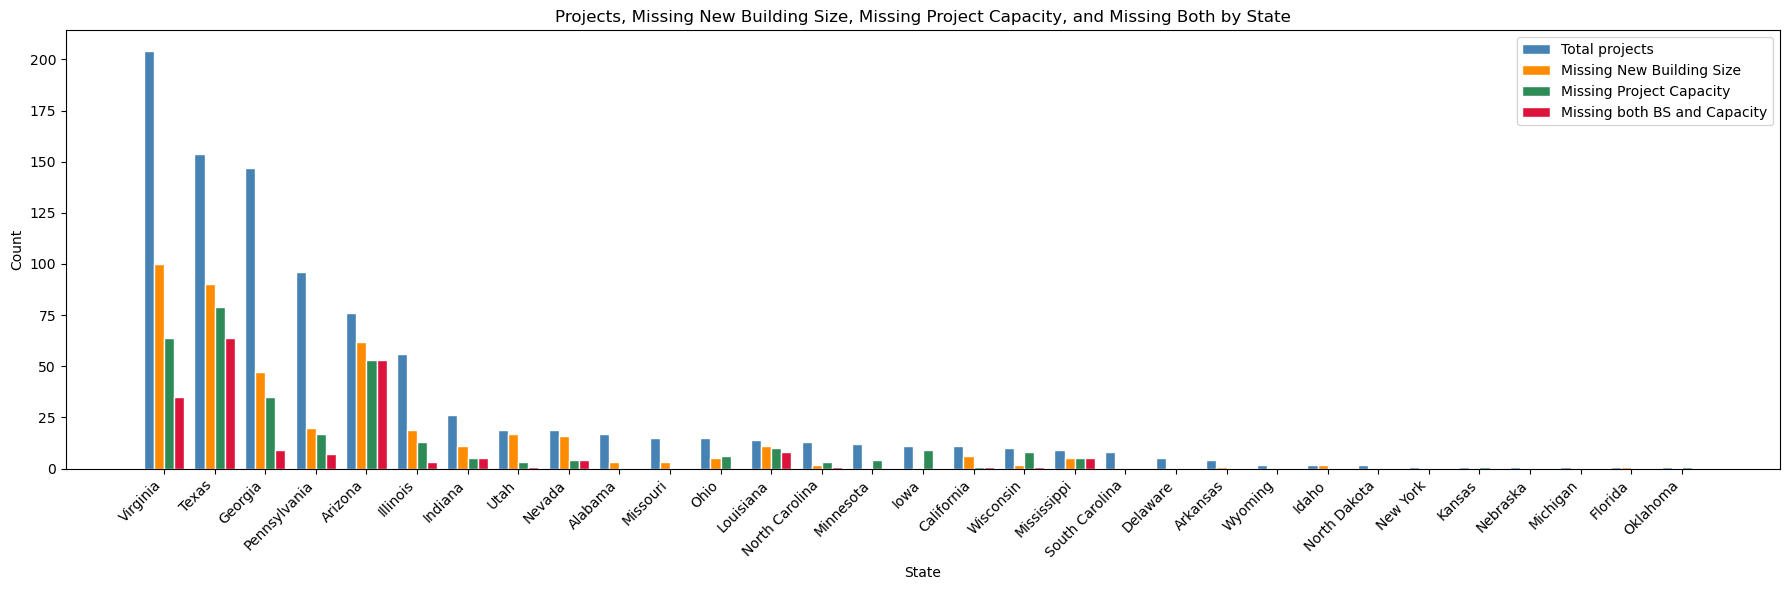

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# State order: descending total project count
counts = data_2['State'].value_counts()
state_order = counts.index

# Missing New Building Size per state (NaN or erroneous 0)
bs_parsed = (
    data_2['New Building Size (Sq. Ft.)']
    .astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
bs_parsed[bs_parsed == 0] = float('nan')
missing_bs = (
    data_2.assign(bs=bs_parsed)
    .groupby('State')['bs']
    .apply(lambda x: x.isna().sum())
    .reindex(state_order, fill_value=0)
)

# Missing Project Capacity per state
pc_parsed = (
    data_2['Project Capacity']
    .astype(str)
    .str.extract(r'([\d.]+)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
)
missing_pc = (
    data_2.assign(pc=pc_parsed)
    .groupby('State')['pc']
    .apply(lambda x: x.isna().sum())
    .reindex(state_order, fill_value=0)
)

missing_both = (
    data_2.assign(bs=bs_parsed, pc=pc_parsed)
    .groupby('State')
    .apply(lambda g: ((g['bs'].isna()) & (g['pc'].isna())).sum())
    .reindex(state_order, fill_value=0)
)

# Grouped bar chart — 4 bars per state
x = np.arange(len(state_order))
width = 0.2   # narrower so 4 bars fit
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - 1.5*width, counts.reindex(state_order), width, label='Total projects',                color='steelblue',  edgecolor='white')
ax.bar(x - 0.5*width, missing_bs,                  width, label='Missing New Building Size',     color='darkorange', edgecolor='white')
ax.bar(x + 0.5*width, missing_pc,                  width, label='Missing Project Capacity',      color='seagreen',   edgecolor='white')
ax.bar(x + 1.5*width, missing_both,                width, label='Missing both BS and Capacity', color='crimson',    edgecolor='white')
ax.set_title('Projects, Missing New Building Size, Missing Project Capacity, and Missing Both by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(state_order, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

Some analysis on missing value by state

In [15]:
# Use your existing bs_parsed and pc_parsed (or recompute them)
counts = data_2.groupby('State').size()
missing_bs = data_2.assign(bs=bs_parsed).groupby('State')['bs'].apply(lambda x: x.isna().sum())
missing_pc = data_2.assign(pc=pc_parsed).groupby('State')['pc'].apply(lambda x: x.isna().sum())

# States where ALL projects have missing Building Size
all_missing_bs = missing_bs[missing_bs == counts.reindex(missing_bs.index)]
# States where ALL projects have missing Project Capacity  
all_missing_pc = missing_pc[missing_pc == counts.reindex(missing_pc.index)]

print("States with ALL missing New Building Size:", list(all_missing_bs.index) if len(all_missing_bs) else "None")
print("States with ALL missing Project Capacity:", list(all_missing_pc.index) if len(all_missing_pc) else "None")

States with ALL missing New Building Size: ['Florida', 'Idaho']
States with ALL missing Project Capacity: ['Kansas', 'Oklahoma']


In [16]:
# Use your existing counts, missing_bs, missing_pc (and bs_parsed, pc_parsed from data_2)
counts = data_2.groupby('State').size()
missing_bs = data_2.assign(bs=bs_parsed).groupby('State')['bs'].apply(lambda x: x.isna().sum())
missing_pc = data_2.assign(pc=pc_parsed).groupby('State')['pc'].apply(lambda x: x.isna().sum())

# Align to same index (states in counts)
missing_bs = missing_bs.reindex(counts.index, fill_value=0)
missing_pc = missing_pc.reindex(counts.index, fill_value=0)

# Fraction missing per state
pct_missing_bs = missing_bs / counts
pct_missing_pc = missing_pc / counts

# States with >50% missing New Building Size
states_high_missing_bs = pct_missing_bs[pct_missing_bs > 0.5].index.tolist()
# States with >50% missing Project Capacity
states_high_missing_pc = pct_missing_pc[pct_missing_pc > 0.5].index.tolist()

print("States with >50% missing New Building Size:", states_high_missing_bs if states_high_missing_bs else "None")
print("States with >50% missing Project Capacity:", states_high_missing_pc if states_high_missing_pc else "None")

States with >50% missing New Building Size: ['Arizona', 'California', 'Florida', 'Idaho', 'Louisiana', 'Mississippi', 'Nevada', 'Texas', 'Utah']
States with >50% missing Project Capacity: ['Arizona', 'Iowa', 'Kansas', 'Louisiana', 'Mississippi', 'Oklahoma', 'Texas', 'Wisconsin']


## Missing Data Imputation

We want to impute the capacity and the new buliding size separately using linear interpolation on these available numeric values: capacity, new building size, existing building size, and TIV

If a project missing new building size is located in a state with >50% missing New Building size, then this project will run linear interpolation for the whole country, as the informaiton within state is to sparse. On the other hand, If a project missig value is located in a state with missing value <50%, then use the state's observation as the base for training the linear model. 

Same thing applies for imputation for project capacity. 

The list of states with high missing artes are defined in the previous cell, stored in states_high_missing_bs and states_high_missing_pc

was_missing_new_building_size: 423 flagged
was_missing_project_capacity:  321 flagged

New Building Size — remaining NaN after imputation: 0 (all features also missing for these rows)
Project Capacity  — remaining NaN after imputation: 0 (all features also missing for these rows)

data_3 shape: (953, 37)


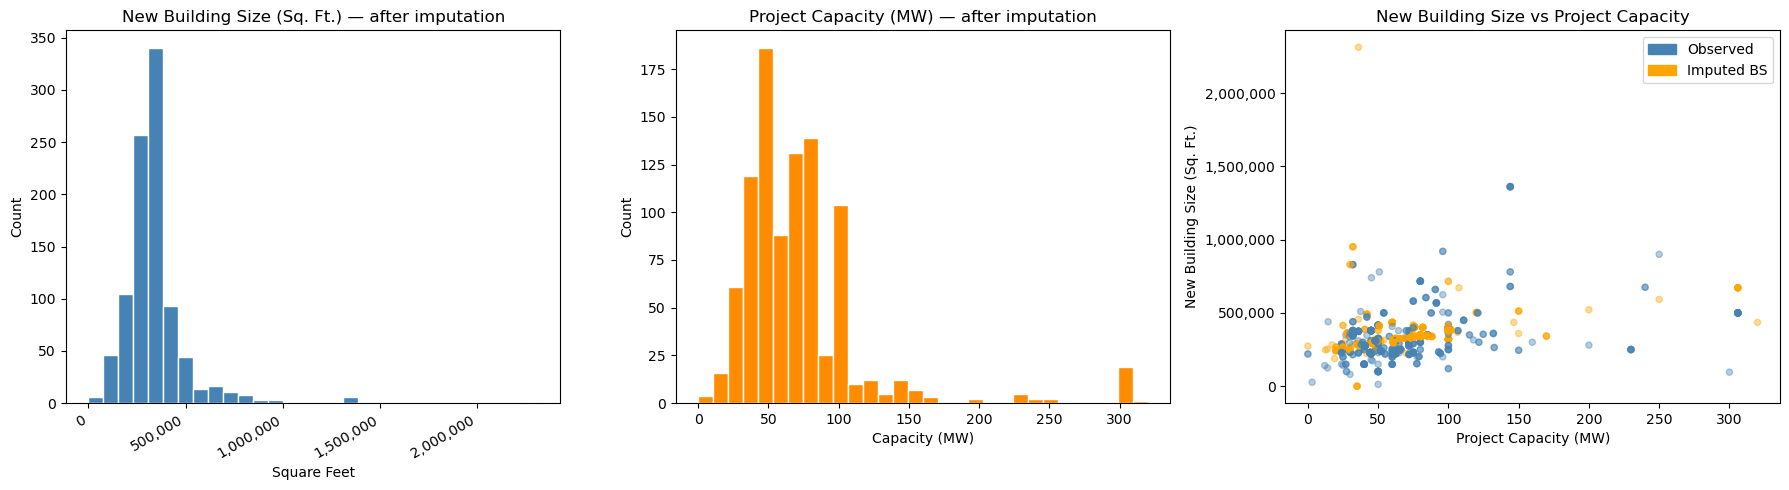

In [31]:
from sklearn.linear_model import LinearRegression
from itertools import combinations
import numpy as np

# ── Step 1: parse numeric working columns into data_2 ──────────────────────
df = data_2.copy()

df['_bs'] = (
    df['New Building Size (Sq. Ft.)']
    .astype(str).str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
df.loc[df['_bs'] == 0, '_bs'] = np.nan

df['_pc'] = (
    df['Project Capacity']
    .astype(str).str.extract(r'([\d.]+)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
)

df['_ebs'] = (
    df['Existing Building Size (Sq. Ft.)']
    .astype(str).str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
df.loc[df['_ebs'] == 0, '_ebs'] = np.nan

df['_tiv'] = pd.to_numeric(df['TIV (USD)'], errors='coerce')

# ── Step 2: flag original missingness → data_3 ─────────────────────────────
data_3 = df.copy()
data_3['was_missing_new_building_size'] = data_3['_bs'].isna()
data_3['was_missing_project_capacity']  = data_3['_pc'].isna()

print(f"was_missing_new_building_size: {data_3['was_missing_new_building_size'].sum()} flagged")
print(f"was_missing_project_capacity:  {data_3['was_missing_project_capacity'].sum()} flagged")

# ── Step 3: helper ─────────────────────────────────────────────────────────
# ALL_FEATS_BS / ALL_FEATS_PC: full candidate feature sets (originally-observed only).
# For a given missing row we try the largest subset of features that are
# (a) non-missing in that row and (b) produce enough training rows in scope.
# Feature subsets are tried in descending size order; the first that works wins.

ALL_FEATS_BS = ['_pc', '_ebs', '_tiv']   # originally-observed PC only
ALL_FEATS_PC = ['_bs', '_ebs', '_tiv']   # originally-observed BS only

def _feature_subsets(feature_cols):
    """Yield all non-empty subsets of feature_cols, largest first."""
    for size in range(len(feature_cols), 0, -1):
        for subset in combinations(feature_cols, size):
            yield list(subset)

def _impute_one(row_idx, scope, target_col, all_features, original_target):
    """
    Impute a single missing value for row_idx.
    - scope        : DataFrame to train on
    - target_col   : '_bs' or '_pc' (working column, may already have imputed values)
    - all_features : full candidate feature list
    - original_target : Series of originally-observed target values (no imputed values)
                        used so training always uses ground-truth targets only
    Returns float or np.nan.
    """
    row = scope.loc[row_idx]
    # features available in this specific row
    row_avail = [f for f in all_features if pd.notna(row[f])]
    if not row_avail:
        return np.nan   # nothing to impute from

    for feats in _feature_subsets(row_avail):
        # training rows: originally observed target + all chosen features non-null
        train_mask = original_target.reindex(scope.index).notna()
        train = scope[train_mask].dropna(subset=feats)
        if len(train) < 2:
            continue
        X_train = train[feats].values
        y_train = original_target.reindex(train.index).values
        model = LinearRegression().fit(X_train, y_train)
        pred = model.predict([row[feats].values])[0]
        return max(pred, 0)   # clip negatives

    return np.nan

# ── Step 4: impute New Building Size ───────────────────────────────────────
# Keep a snapshot of originally-observed BS (never include imputed values in training)
original_bs = data_3['_bs'].copy()

for idx in data_3[data_3['_bs'].isna()].index:
    state = data_3.loc[idx, 'State']
    scope = data_3 if state in states_high_missing_bs else data_3[data_3['State'] == state]
    val = _impute_one(idx, scope, '_bs', ALL_FEATS_BS, original_bs)
    if pd.notna(val):
        data_3.loc[idx, '_bs'] = val

still_missing_bs = data_3['_bs'].isna().sum()
print(f"\nNew Building Size — remaining NaN after imputation: {still_missing_bs} "
      f"(all features also missing for these rows)")

# ── Step 5: impute Project Capacity ────────────────────────────────────────
original_pc = data_3['_pc'].copy()

for idx in data_3[data_3['_pc'].isna()].index:
    state = data_3.loc[idx, 'State']
    scope = data_3 if state in states_high_missing_pc else data_3[data_3['State'] == state]
    val = _impute_one(idx, scope, '_pc', ALL_FEATS_PC, original_pc)
    if pd.notna(val):
        data_3.loc[idx, '_pc'] = val

still_missing_pc = data_3['_pc'].isna().sum()
print(f"Project Capacity  — remaining NaN after imputation: {still_missing_pc} "
      f"(all features also missing for these rows)")

# ── Step 6: write back clean numeric columns, drop temporaries ─────────────
data_3['New Building Size (Sq. Ft.) (Numeric)'] = data_3['_bs']
data_3['Project Capacity (Numeric)']            = data_3['_pc']
data_3 = data_3.drop(columns=['_bs', '_pc', '_ebs', '_tiv'])

print(f"\ndata_3 shape: {data_3.shape}")

# ── Step 7: plots ──────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — New Building Size histogram
bs_vals = data_3['New Building Size (Sq. Ft.) (Numeric)'].dropna()
axes[0].hist(bs_vals, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('New Building Size (Sq. Ft.) — after imputation')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Plot 2 — Project Capacity histogram
pc_vals = data_3['Project Capacity (Numeric)'].dropna()
axes[1].hist(pc_vals, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Project Capacity (MW) — after imputation')
axes[1].set_xlabel('Capacity (MW)')
axes[1].set_ylabel('Count')

# Plot 3 — scatter: capacity vs new building size, colour by imputation status
scatter_idx = bs_vals.index.intersection(pc_vals.index)
colors = data_3.loc[scatter_idx, 'was_missing_new_building_size'].map(
    {True: 'orange', False: 'steelblue'}
)
axes[2].scatter(
    data_3.loc[scatter_idx, 'Project Capacity (Numeric)'],
    data_3.loc[scatter_idx, 'New Building Size (Sq. Ft.) (Numeric)'],
    c=colors, alpha=0.4, s=20
)
axes[2].legend(handles=[
    mpatches.Patch(color='steelblue', label='Observed'),
    mpatches.Patch(color='orange',    label='Imputed BS'),
])
axes[2].set_xlabel('Project Capacity (MW)')
axes[2].set_ylabel('New Building Size (Sq. Ft.)')
axes[2].set_title('New Building Size vs Project Capacity')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


## Calculate Total Campus Size 

Compute `total_white_space_sqft`, `total_grey_space_sqft`, and `total_campus_sqft` for each project phase.

different prjects may be in the same umbrella, which they will share the same Umbrella Project ID, with these distinct umbrella IDs then comes a metric called total campus size, which is as follows:

Let:

    u = umbrella ID (campus)
    i = current project phase within that umbrella
    j = earlier phases within the same umbrella
    E_u = existing building size for umbrella u
    N_j = new building size for phase j
    N_i = new building size for the current phase i
    R_s = power infrastructure ratio for state s

IT_space_{u,i} =
    E_u
    + Σ N_j   (for all phases j < i under the same umbrella u)
    + N_i

Total_campus_size_{u,i} = (E_u + Σ_{j<i} N_j + N_i) × (1 + R_s) 
                        = IT_space_{u,i} × (1 + R_s) 


In [32]:
# Define the grey space ratio by state
grey_space_ratio_by_state = {
    "Wisconsin": 0.20,
    "Wyoming": 0.18,
    "Louisiana": 0.20,
    "Arkansas": 0.20,
    "Utah": 0.18,
    "Nevada": 0.18,
    "Texas": 0.18,
    "Indiana": 0.20,
    "Georgia": 0.20,
    "Alabama": 0.20,
    "North Dakota": 0.22,
    "Missouri": 0.22,
    "Minnesota": 0.22,
    "Arizona": 0.18,
    "Illinois": 0.20,
    "Delaware": 0.22,
    "Nebraska": 0.22,
    "Florida": 0.20,
    "Virginia": 0.18,
    "North Carolina": 0.20,
    "Pennsylvania": 0.20,
    "California": 0.20,
    "Mississippi": 0.22,
    "South Carolina": 0.22,
    "Ohio": 0.20,
    "Idaho": 0.22,
    "New York": 0.25,
    "Michigan": 0.22,
    "Iowa": 0.22
}

default_ratio = 0.20

Impute missing values for existing building size

In [33]:
# ── Step 1: parse Existing Building Size into a numeric working column ─────
# (data_3 already has _ebs dropped after Cell 32; re-parse from the original string column)
data_3['_ebs'] = (
    data_3['Existing Building Size (Sq. Ft.)']
    .astype(str).str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
data_3.loc[data_3['_ebs'] == 0, '_ebs'] = np.nan

# ── Step 2: impute missing Existing Building Size using the same
# linear-regression logic already applied to New Building Size and
# Project Capacity in Cell 32. ────────────────────────────────────────────
# Features: the imputed numeric columns for BS and PC written back in Cell 32.
data_3['_bs_num'] = data_3['New Building Size (Sq. Ft.) (Numeric)']
data_3['_pc_num'] = data_3['Project Capacity (Numeric)']
data_3['_tiv_num'] = pd.to_numeric(data_3['TIV (USD)'], errors='coerce')

ALL_FEATS_EBS = ['_bs_num', '_pc_num', '_tiv_num']

# Pre-compute high-missing-EBS states (same threshold as BS/PC: >50%)
_counts_st   = data_3.groupby('State').size()
_miss_ebs_st = (
    data_3.assign(_e=data_3['_ebs'])
    .groupby('State')['_e']
    .apply(lambda x: x.isna().sum())
)
_pct_miss_ebs = (_miss_ebs_st / _counts_st.reindex(_miss_ebs_st.index)).fillna(0)
states_high_missing_ebs = _pct_miss_ebs[_pct_miss_ebs > 0.5].index.tolist()
print('States with >50% missing Existing Building Size:', states_high_missing_ebs)

original_ebs = data_3['_ebs'].copy()

for idx in data_3[data_3['_ebs'].isna()].index:
    state = data_3.loc[idx, 'State']
    scope = data_3 if state in states_high_missing_ebs else data_3[data_3['State'] == state]
    val = _impute_one(idx, scope, '_ebs', ALL_FEATS_EBS, original_ebs)
    if pd.notna(val):
        data_3.loc[idx, '_ebs'] = val

still_missing_ebs = data_3['_ebs'].isna().sum()
print(f'Existing Building Size — remaining NaN after imputation: {still_missing_ebs}')

data_3['Existing Building Size (Sq. Ft.) (Numeric)'] = data_3['_ebs']

# Drop temporary columns
data_3 = data_3.drop(columns=['_ebs', '_bs_num', '_pc_num', '_tiv_num'])
print(f'data_3 shape after EBS imputation: {data_3.shape}')


States with >50% missing Existing Building Size: ['Arizona', 'Arkansas', 'Delaware', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Louisiana', 'Minnesota', 'Mississippi', 'Missouri', 'Nevada', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Carolina', 'Texas', 'Utah', 'Virginia', 'Wisconsin', 'Wyoming']
Existing Building Size — remaining NaN after imputation: 0
data_3 shape after EBS imputation: (953, 38)


Assign a phase for each project under the same umbrella ID

In [34]:
# ── Step 3: campus baseline = max(Existing Building Size) per umbrella ──────
# Projects without an umbrella ID are treated as standalone (single-phase campus).
# For standalone projects, the baseline is their own existing building size.

uid_col = 'Umbrella Project ID'

# Fill missing umbrella IDs with a synthetic unique key so every row belongs
# to exactly one campus.
data_3['_uid'] = data_3[uid_col].fillna(data_3['Project ID'].astype(str))

campus_baseline = (
    data_3.groupby('_uid')['Existing Building Size (Sq. Ft.) (Numeric)']
    .max()
    .rename('_campus_baseline')
)
data_3 = data_3.join(campus_baseline, on='_uid')

print('Campus baseline computed.')
print(f'  Non-null campus baselines: {data_3["_campus_baseline"].notna().sum()} / {len(data_3)}')

# ── Step 4: phase ordering within each umbrella ──────────────────────────────
# Use Kick-Off date as the primary sort key; tie-break on AFE date.
data_3['_kickoff_dt'] = pd.to_datetime(data_3['Kick-Off'], format='%Y-%m', errors='coerce')
data_3['_afe_dt']     = pd.to_datetime(data_3['AFE date'],  format='%Y-%m', errors='coerce')

data_3 = data_3.sort_values(['_uid', '_kickoff_dt', '_afe_dt']).reset_index(drop=True)

# Assign a 0-based phase index within each umbrella
data_3['phase_index'] = data_3.groupby('_uid').cumcount()

print('Phase ordering computed.')
print(data_3[['Project ID', uid_col, 'phase_index', '_kickoff_dt']].head(10).to_string())


Campus baseline computed.
  Non-null campus baselines: 953 / 953
Phase ordering computed.
   Project ID  Umbrella Project ID  phase_index _kickoff_dt
0   301069193                736.0            0  2029-03-01
1   301150544              72271.0            0  2029-04-01
2   301083916              72271.0            1  2029-06-01
3   301150841              72271.0            2  2029-08-01
4   301083917              72271.0            3  2029-10-01
5   301150858              72271.0            4  2029-12-01
6   301065886              72462.0            0  2030-06-01
7   301065901              72462.0            1  2030-12-01
8   301065903              72462.0            2  2031-06-01
9   301065909              72462.0            3  2031-12-01


In [35]:
# ── Step 5: cumulative IT building space per phase ───────────────────────────
# IT_campus_space = campus_baseline + cumulative sum of new_building_size
# (including the current phase) within each umbrella, ordered by phase_index.

# Data are already sorted by (_uid, phase_index) from the previous cell.
data_3['_new_bs'] = data_3['New Building Size (Sq. Ft.) (Numeric)'].fillna(0)

# Cumulative sum of new building size within each campus up to and including
# the current phase.
data_3['_cumsum_new_bs'] = (
    data_3.groupby('_uid')['_new_bs']
    .cumsum()
)

# IT campus space at this phase
data_3['IT_campus_space_sqft'] = (
    data_3['_campus_baseline'].fillna(0)
    + data_3['_cumsum_new_bs']
)

print('Cumulative IT campus space computed.')
sample_uid = data_3[data_3.groupby('_uid')['_uid'].transform('count') > 1]['_uid'].iloc[0]
print(data_3[data_3['_uid'] == sample_uid][
    ['Project ID', '_uid', 'phase_index', '_campus_baseline',
     '_new_bs', '_cumsum_new_bs', 'IT_campus_space_sqft']
].to_string())


Cumulative IT campus space computed.
   Project ID     _uid  phase_index  _campus_baseline        _new_bs  _cumsum_new_bs  IT_campus_space_sqft
1   301150544  72271.0            0         2560000.0  500000.000000    5.000000e+05          3.060000e+06
2   301083916  72271.0            1         2560000.0  435350.464952    9.353505e+05          3.495350e+06
3   301150841  72271.0            2         2560000.0  500000.000000    1.435350e+06          3.995350e+06
4   301083917  72271.0            3         2560000.0  435350.464952    1.870701e+06          4.430701e+06
5   301150858  72271.0            4         2560000.0  500000.000000    2.370701e+06          4.930701e+06


In [36]:
# ── Step 6-8: grey space ratio, power infrastructure space, total campus size ─

# Map each row's state to its grey space ratio (default 0.20 if not in dict)
data_3['_grey_ratio'] = data_3['State'].map(grey_space_ratio_by_state).fillna(default_ratio)

# Power infrastructure space
data_3['campus_grey_space_sqft'] = (
    data_3['IT_campus_space_sqft'] * data_3['_grey_ratio']
).round(0)

# IT (white) space = what we already computed
data_3['campus_white_space_sqft'] = data_3['IT_campus_space_sqft'].round(0)

# Total campus footprint = white + grey
data_3['campus_sqft'] = (
    data_3['campus_white_space_sqft'] + data_3['campus_grey_space_sqft']
)

# Clean up internal working columns
data_3 = data_3.drop(columns=[
    '_uid', '_campus_baseline', '_kickoff_dt', '_afe_dt',
    '_new_bs', '_cumsum_new_bs', '_grey_ratio', 'IT_campus_space_sqft'
])

print('Final campus size columns computed.')
print()
print('Fill rates:')
for col in ['campus_white_space_sqft', 'campus_grey_space_sqft', 'campus_sqft']:
    n = data_3[col].notna().sum()
    print(f'  {col}: {n} / {len(data_3)} non-null')
print()
print('Sample output:')
print(data_3[['Project ID', 'Umbrella Project ID', 'phase_index',
              'campus_white_space_sqft', 'campus_grey_space_sqft', 'campus_sqft']]
      .head(15).to_string())


Final campus size columns computed.

Fill rates:
  campus_white_space_sqft: 953 / 953 non-null
  campus_grey_space_sqft: 953 / 953 non-null
  campus_sqft: 953 / 953 non-null

Sample output:
    Project ID  Umbrella Project ID  phase_index  campus_white_space_sqft  campus_grey_space_sqft  campus_sqft
0    301069193                736.0            0                3036553.0                607311.0    3643864.0
1    301150544              72271.0            0                3060000.0                550800.0    3610800.0
2    301083916              72271.0            1                3495350.0                699070.0    4194420.0
3    301150841              72271.0            2                3995350.0                719163.0    4714513.0
4    301083917              72271.0            3                4430701.0                886140.0    5316841.0
5    301150858              72271.0            4                4930701.0                887526.0    5818227.0
6    301065886              72462

## Calculate Total Energy Density per Project

In [41]:
# total_campus_expansion_sqft = new building size * (1 + grey space ratio)
# Look up ratio from state via dictionary; use default_ratio if state not in dict
data_3['total_campus_expansion_sqft'] = (
    data_3['New Building Size (Sq. Ft.) (Numeric)']
    * (1 + data_3['State'].map(grey_space_ratio_by_state).fillna(default_ratio))
).round(0)

## Filter out low capacity projects

In [42]:
pct = data_3['Project Capacity (Numeric)'].quantile(np.arange(0.1, 1.0, 0.1))
pct.index = [f"{int(i*100)}th" for i in pct.index]
print(pct)

10th     32.000000
20th     42.000000
30th     46.000000
40th     52.000000
50th     64.000000
60th     73.130939
70th     79.069430
80th     91.416213
90th    100.000000
Name: Project Capacity (Numeric), dtype: float64


60 MW seems like a reasonable threshold to define a worthwile beach head, as we can neglect the bottom half projects in terms of capacity.

In [43]:
# Filter: keep projects with Project Capacity >= 50
data_4 = data_3[data_3['Project Capacity (Numeric)'] >= 60].copy()

# Show drop in observations
print(f"data_3: {len(data_3)} observations")
print(f"data_4: {len(data_4)} observations")


data_3: 953 observations
data_4: 554 observations


### output csv

In [45]:
# Save to CSV
data_4.to_csv("engine_lab_filtered.csv", index=False)

# Save to excel
data_4.to_excel("engine_lab_filtered.xlsx", index=False, engine="openpyxl")